In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Path to dataset files: /kaggle/input/heart-failure-prediction


In [2]:
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

df = pd.read_csv(path + "/heart.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Balance:")
print(df['HeartDisease'].value_counts())

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
First 5 Rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Dataset Shape:
(918, 12)

Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP  

The dataset contains 918 rows and 12 columns.

No missing values were found in the dataset.

The classes are relatively balanced between patients with heart disease and patients without heart disease.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns

label_encoder = LabelEncoder()

categorical_columns = [
    'Sex',
    'ChestPainType',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Separate features and label

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (734, 11)
Testing set shape: (184, 11)


# Task 1.2 — Prepare the Data

The categorical columns were converted into numerical values using LabelEncoder.

The features (X) and target label (y) were separated.

The dataset was split into training and testing sets using an 80/20 ratio.

The random_state was set to 42 to ensure reproducible results.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Accuracy: 0.8695652173913043
Precision: 0.8611111111111112
Recall: 0.9117647058823529
F1-score: 0.8857142857142857


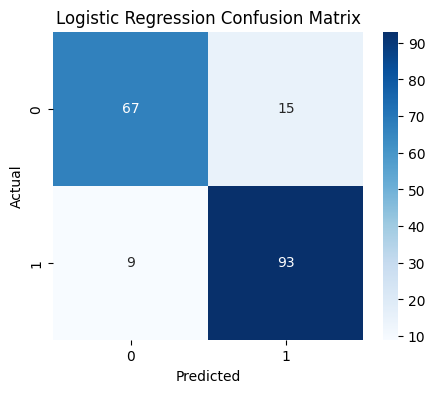

Random Forest
Accuracy: 0.875
Precision: 0.8761904761904762
Recall: 0.9019607843137255
F1-score: 0.8888888888888888


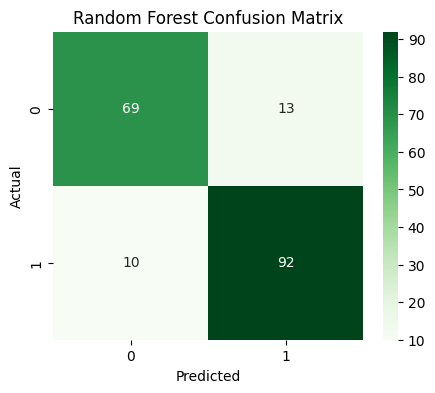

KNN
Accuracy: 0.6956521739130435
Precision: 0.7254901960784313
Recall: 0.7254901960784313
F1-score: 0.7254901960784313


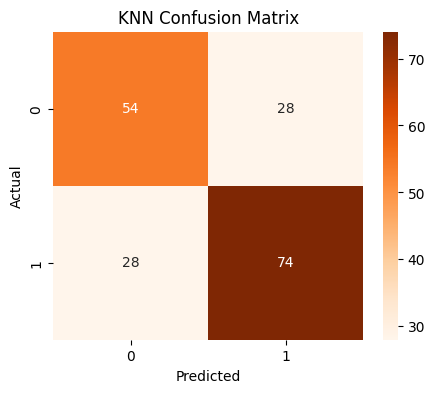

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.869565   0.861111  0.911765  0.885714
1        Random Forest  0.875000   0.876190  0.901961  0.888889
2                  KNN  0.695652   0.725490  0.725490  0.725490


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression")
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1-score:", lr_f1)

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("KNN")
print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1-score:", knn_f1)

cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy': [lr_accuracy, rf_accuracy, knn_accuracy],
    'Precision': [lr_precision, rf_precision, knn_precision],
    'Recall': [lr_recall, rf_recall, knn_recall],
    'F1-Score': [lr_f1, rf_f1, knn_f1]
})

print(results)

Three machine learning models were trained and evaluated:
- Logistic Regression
- Random Forest
- KNN

The models were evaluated using accuracy, precision, recall, and F1-score.

Random Forest achieved the best overall performance on the dataset.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5554 - loss: 8.2649 - val_accuracy: 0.6054 - val_loss: 1.9476
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6099 - loss: 5.1193 - val_accuracy: 0.6599 - val_loss: 1.3322
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6065 - loss: 3.7501 - val_accuracy: 0.6803 - val_loss: 0.8543
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5877 - loss: 2.6038 - val_accuracy: 0.6667 - val_loss: 0.8503
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5911 - loss: 1.9247 - val_accuracy: 0.5510 - val_loss: 0.9110
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6457 - loss: 1.5940 - val_accuracy: 0.5578 - val_loss: 0.7639
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6440 - loss: 1.3094 - val_accuracy: 0.6599 - val_loss: 0.6648
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5928 - loss: 1.2872 - val_accuracy: 0.5850 - val_loss

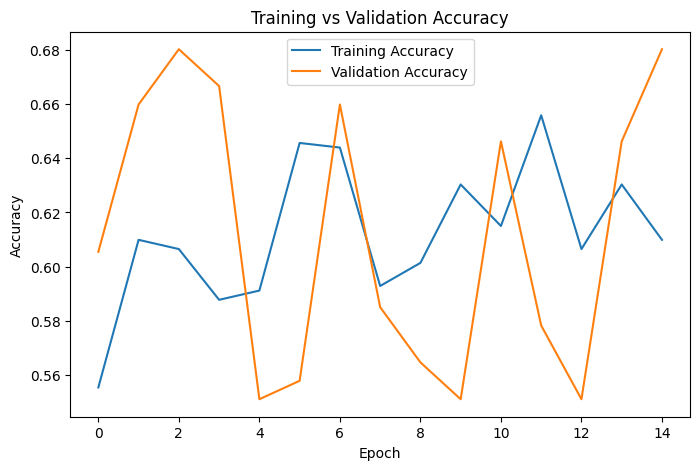

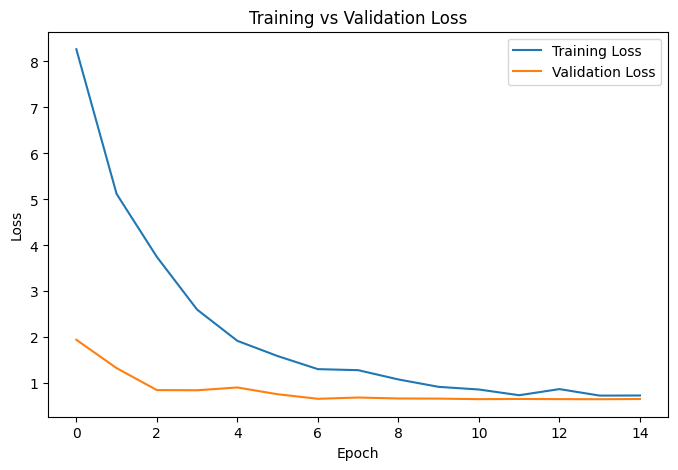

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32
)

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

A neural network was built using Keras Dense layers with ReLU and Sigmoid activation functions.

Dropout layers were added to reduce overfitting.

The model was trained for 15 epochs using the training dataset.

Training and validation accuracy and loss curves were plotted to monitor the model performance during training.

In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nn_pred_probs = model.predict(X_test)
nn_pred = (nn_pred_probs > 0.5).astype(int).flatten()

nn_accuracy = accuracy_score(y_test, nn_pred)
nn_precision = precision_score(y_test, nn_pred)
nn_recall = recall_score(y_test, nn_pred)
nn_f1 = f1_score(y_test, nn_pred)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN', 'Neural Network'],
    'Accuracy': [lr_accuracy, rf_accuracy, knn_accuracy, nn_accuracy],
    'Precision': [lr_precision, rf_precision, knn_precision, nn_precision],
    'Recall': [lr_recall, rf_recall, knn_recall, nn_recall],
    'F1-Score': [lr_f1, rf_f1, knn_f1, nn_f1]
})

print(results.to_string(index=False))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.869565   0.861111 0.911765  0.885714
      Random Forest  0.875000   0.876190 0.901961  0.888889
                KNN  0.695652   0.725490 0.725490  0.725490
     Neural Network  0.728261   0.754902 0.754902  0.754902


Based on the summary table, the traditional machine learning models performed better than the Neural Network. The Neural Network was worse because deep learning models require a much larger dataset to train effectively compared to our heart dataset, and the performance was also affected because the features were not scaled before training